## Предобработка данных

Выгрузим данные в датафрейм.

In [81]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score

In [82]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
df = pd.read_csv('/Users/tagirbikmuhametov/Documents/Бикмухаметов Тагир/2 курс/Курсач/Результаты.csv')
df.head(3)

,год,время года,класс,лига,название команды1,название команды2,очки команды1,очки команды2,сила команды1,сила команды2,результат боя
0,2019,весна,4,высшая,1-2-3-4 (Санкт-Петербург),Фрактал 4 (Санкт-Петербург),40,51,(9; 2),(8; 3),поражение
1,2019,весна,4,высшая,1-2-3-4 (Санкт-Петербург),ЮМШ-4 (Санкт-Петербург),54,33,(9; 2),(7; 2),победа
2,2019,весна,4,высшая,1-2-3-4 (Санкт-Петербург),Аксиома (Набережные Челны),57,13,(9; 2),(4; 3),победа


Создадим отдельные колонки с количеством плюсов и количеством минусов команд.

In [85]:
df[['Плюсы команды 1', 'Минусы команды 1']] = df['сила команды1'].str.extract(r'\((\d+);\s*(\d+)\)')
df[['Плюсы команды 2', 'Минусы команды 2']] = df['сила команды2'].str.extract(r'\((\d+);\s*(\d+)\)')
cols = ['Плюсы команды 1', 'Минусы команды 1', 'Плюсы команды 2', 'Минусы команды 2']
for col in cols:
    df[col] = pd.to_numeric(df[col])

## Первичный анализ

Мы сейчас будем красить точки. Поскольку мы работаем с дискретными величинами, к точкам добавим тряску, чтобы они друг друга не перекрывали

In [86]:
def get_jiga(series: pd.Series, amount: int =0.3) -> pd.Series:
    return series + np.random.uniform(-amount, amount, len(series))

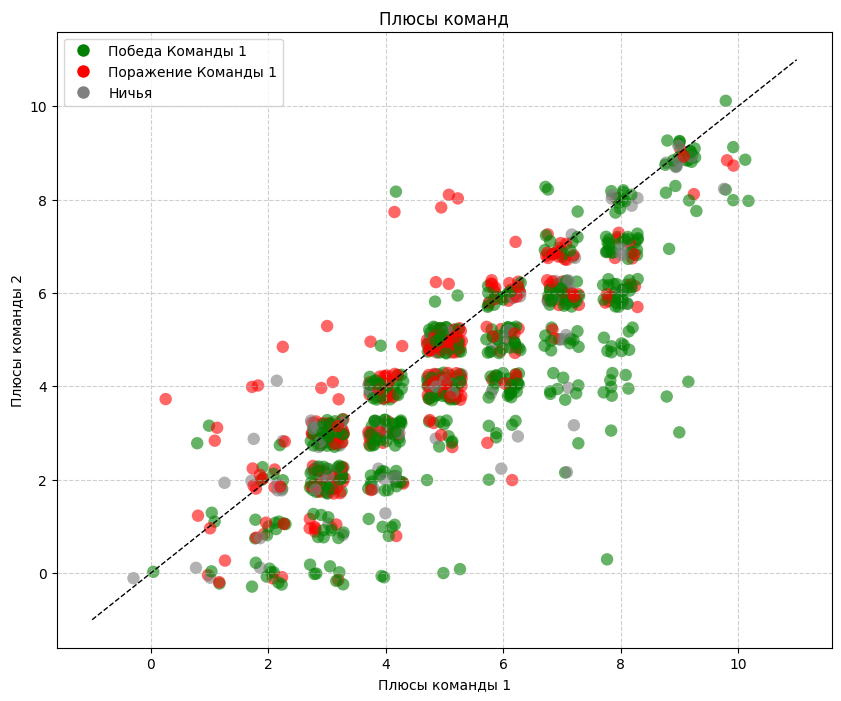

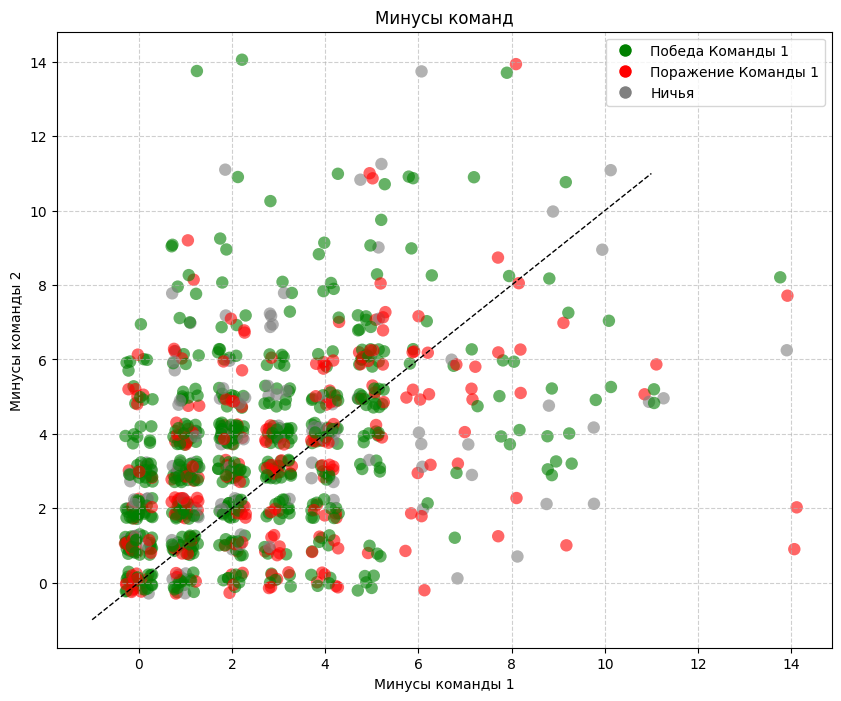

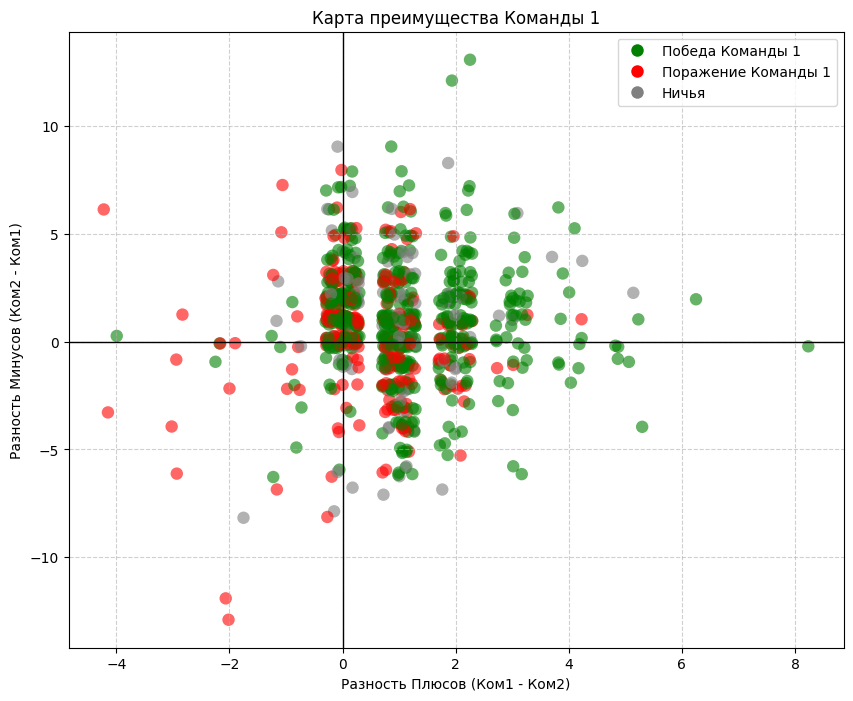

In [87]:
from matplotlib.lines import Line2D

color_map = {
    'победа': 'green',
    'поражение': 'red',
    'ничья': 'gray'
}

colors = df['результат боя'].map(color_map)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Победа Команды 1', 
           markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Поражение Команды 1', 
           markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Ничья', 
           markerfacecolor='gray', markersize=10)
]

plt.figure(figsize=(10, 8))
limit_min = min(df['Плюсы команды 1'].min(), df['Плюсы команды 2'].min()) - 1
limit_max = max(df['Плюсы команды 1'].max(), df['Плюсы команды 2'].max()) + 1
plt.plot([limit_min, limit_max], [limit_min, limit_max], color='black', linestyle='--', linewidth=1)
plt.scatter(
    get_jiga(df['Плюсы команды 1']), 
    get_jiga(df['Плюсы команды 2']), 
    c=colors, alpha=0.6, s=80, edgecolors='none'
)
plt.title('Плюсы команд')
plt.xlabel('Плюсы команды 1')
plt.ylabel('Плюсы команды 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(handles=legend_elements)
plt.show()

plt.figure(figsize=(10, 8))
limit_min = min(df['Плюсы команды 1'].min(), df['Плюсы команды 2'].min()) - 1
limit_max = max(df['Плюсы команды 1'].max(), df['Плюсы команды 2'].max()) + 1
plt.plot([limit_min, limit_max], [limit_min, limit_max], color='black', linestyle='--', linewidth=1)
plt.scatter(
    get_jiga(df['Минусы команды 1']), 
    get_jiga(df['Минусы команды 2']), 
    c=colors, alpha=0.6, s=80, edgecolors='none'
)
plt.title('Минусы команд')
plt.xlabel('Минусы команды 1')
plt.ylabel('Минусы команды 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(handles=legend_elements)
plt.show()

x_diff = df['Плюсы команды 1'] - df['Плюсы команды 2']
y_diff = df['Минусы команды 2'] - df['Минусы команды 1']

plt.figure(figsize=(10, 8))
plt.scatter(
    get_jiga(x_diff), 
    get_jiga(y_diff), 
    c=colors, alpha=0.6, s=80, edgecolors='none'
)
plt.title('Карта преимущества Команды 1')
plt.xlabel('Разность Плюсов (Ком1 - Ком2)')
plt.ylabel('Разность Минусов (Ком2 - Ком1)')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(handles=legend_elements)
plt.show()

***Выводы***

Выводы сделать трудно: можно лишь притянуть за уши как-то, что количество плюсов может как-то говорить о победоносности команды. Попробуем построить гистограмму по количеству побед и поражений в зависимости от плюсов команды

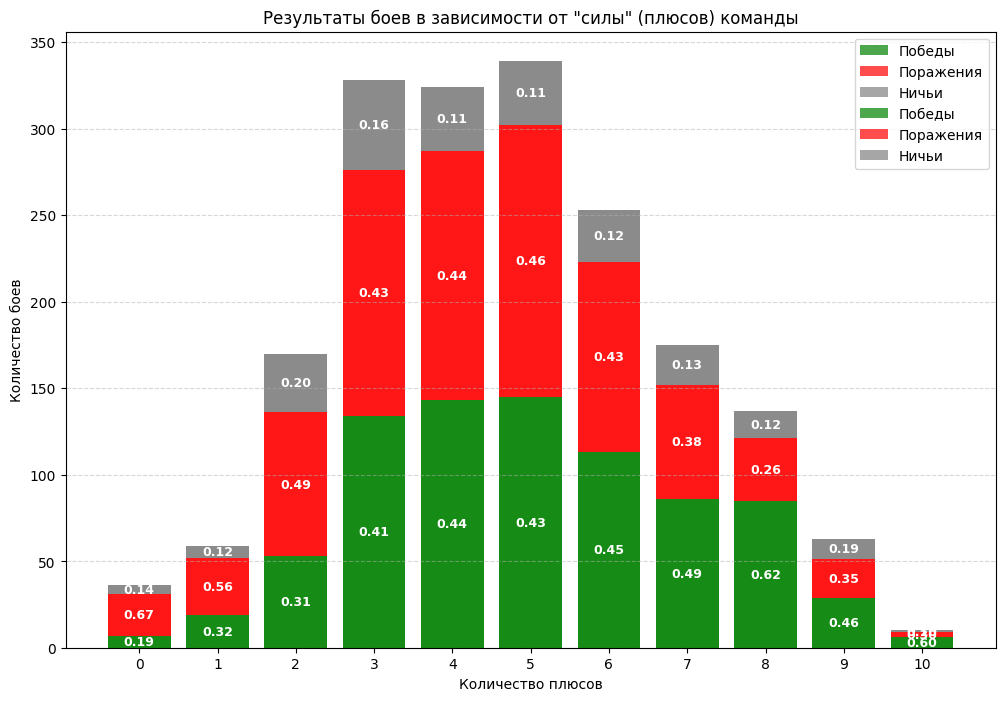

In [88]:
df1 = pd.DataFrame({
    'pluses': df['Плюсы команды 1'],
    'result': df['результат боя']
})

def invert_result(res: str) -> str:
    if res == 'победа': return 'поражение'
    if res == 'поражение': return 'победа'
    return 'ничья'

df2 = pd.DataFrame({
    'pluses': df['Плюсы команды 2'],
    'result': df['результат боя'].apply(invert_result)
})

plot_data = pd.concat([df1, df2], ignore_index=True)

counts = plot_data.groupby(['pluses', 'result']).size().unstack(fill_value=0)

counts = counts.sort_index()

plt.figure(figsize=(12, 8))

p1 = plt.bar(counts.index, counts['победа'], color='green', label='Победы', alpha=0.7)
p2 = plt.bar(counts.index, counts['поражение'], bottom=counts['победа'], 
             color='red', label='Поражения', alpha=0.7)
p3 = plt.bar(counts.index, counts['ничья'], bottom=counts['победа'] + counts['поражение'], 
             color='gray', label='Ничьи', alpha=0.7)

totals = counts.sum(axis=1)

def add_labels(bars, bottom_series=None):
    for idx, rect in enumerate(bars):
        height = rect.get_height()
        if height > 0:
            x = rect.get_x() + rect.get_width() / 2
            y_bottom = 0
            if bottom_series is not None:
                y_bottom = bottom_series.iloc[idx]
            y = y_bottom + height / 2
            total = totals.iloc[idx]
            share = height / total
            if share >= 0.04: 
                plt.text(x, y, f"{share:.2f}", ha='center', va='center', 
                         color='white', fontsize=9, fontweight='bold')

add_labels(p1)
add_labels(p2, bottom_series=counts['победа'])
add_labels(p3, bottom_series=counts['победа'] + counts['поражение'])

plt.bar(counts.index, counts['победа'], color='green', label='Победы', alpha=0.7)

plt.bar(counts.index, counts['поражение'], bottom=counts['победа'], 
        color='red', label='Поражения', alpha=0.7)

plt.bar(counts.index, counts['ничья'], bottom=counts['победа'] + counts['поражение'], 
        color='gray', label='Ничьи', alpha=0.7)

plt.xlabel('Количество плюсов')
plt.ylabel('Количество боев')
plt.title('Результаты боев в зависимости от "силы" (плюсов) команды')
plt.xticks(counts.index)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

В целом видно, что совсем слабые команды выигрывают реже. Команды с 3-6 баллами очень близки друг к другу. Команды с 7-10 баллами значительно реже проигрывают.

# Попробуем попредсказывать

Для начала попробуем линейную регрессию. Будем предсказывать результат боя: поражение (0), ничья (1), поражение (2). Для начала попробуем обыкновенный линрег. Используем 10-fold cross-validation

In [89]:
def load_classification_data(filepath):
    df = pd.read_csv(filepath)
    
    def parse_strength(s):
        match = re.match(r'\((\d+);\s*(\d+)\)', str(s).strip())
        return (int(match.group(1)), int(match.group(2))) if match else (0, 0)

    s1 = df['сила команды1'].apply(parse_strength)
    s2 = df['сила команды2'].apply(parse_strength)
    
    X = pd.DataFrame()
    
    X['plus1'], X['minus1'] = zip(*s1)
    X['plus2'], X['minus2'] = zip(*s2)
    
    diff_scores = df['очки команды1'] - df['очки команды2']
    y = diff_scores.apply(lambda x: 2 if x > 3 else (0 if x < -3 else 1))
    
    return X, y

In [ ]:
from IPS_HSE_Bikmukhametov_Tagir_2026.Research.models import FullGDLinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X, y = load_classification_data('Результаты.csv') 

pipeline_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('lin_reg', FullGDLinearRegression(learning_rate=0.01, n_iterations=2000, random_state=42))
])

cv = KFold(n_splits=10, shuffle=True, random_state=42)
mse_scores = cross_val_score(pipeline_simple, X, y, cv=cv, scoring='neg_mean_squared_error')
print(f"Средний RMSE (4 фичи): {np.sqrt(-mse_scores.mean()):.4f}")

Средний RMSE (4 фичи): 0.8503


Попробуем добавить ohe для классов, умножая количество плюсов на атрибут класса. Возможно, окажется, что в более старших классах разность баллов более репрезентативна.

In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer

def get_advanced_features(df):
    def parse_strength(s):
        match = re.match(r'\((\d+);\s*(\d+)\)', str(s).strip())
        return (int(match.group(1)), int(match.group(2))) if match else (0, 0)

    s1 = df['сила команды1'].apply(parse_strength)
    s2 = df['сила команды2'].apply(parse_strength)
    
    X = pd.DataFrame()
    X['plus1'], X['minus1'] = zip(*s1)
    X['plus2'], X['minus2'] = zip(*s2)
    X['класс'] = df['класс']
    
    X['diff_plus'] = X['plus1'] - X['plus2']
    
    diff_scores = df['очки команды1'] - df['очки команды2']
    y = diff_scores.apply(lambda x: 2 if x > 3 else (0 if x < -3 else 1))
    return X, y

X_adv, y_adv = get_advanced_features(pd.read_csv('Результаты.csv'))

def interaction_plus_class(X_input):
    plus1, minus1, plus2, minus2, diff_plus = X_input[:, 0], X_input[:, 1], X_input[:, 2], X_input[:, 3], X_input[:, 4]
    classes_ohe = X_input[:, 5:] 
    
    interactions = classes_ohe * diff_plus[:, np.newaxis]
    
    return np.hstack([X_input[:, :4], interactions])

preprocessor = ColumnTransformer([
    ('base_and_diff', 'passthrough', ['plus1', 'minus1', 'plus2', 'minus2', 'diff_plus']),
    ('ohe_class', OneHotEncoder(drop='first', sparse_output=False), ['класс'])
])

pipeline_inter = Pipeline([
    ('prep', preprocessor),
    ('inter', FunctionTransformer(interaction_plus_class)),
    ('scaler', StandardScaler()),
    ('lin_reg', FullGDLinearRegression(learning_rate=0.01, n_iterations=3000, random_state=42))
])

scores_inter = cross_val_score(pipeline_inter, X_adv, y_adv, cv=cv, scoring='neg_mean_squared_error')
print(f"Средний RMSE (Interactions): {np.sqrt(-scores_inter.mean()):.4f}")

Средний RMSE (Interactions): 0.8521


Не вышло( Попробуем RandomForest. Возьмем за метрику Accuracy. Не забудем о правиле: ничья выставляется при разнице баллов не более 3

In [79]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestClassifier

def load_classification_data(filepath):
    df = pd.read_csv(filepath)
    
    def parse_strength(s):
        match = re.match(r'\((\d+);\s*(\d+)\)', str(s).strip())
        return (int(match.group(1)), int(match.group(2))) if match else (0, 0)

    s1 = df['сила команды1'].apply(parse_strength)
    s2 = df['сила команды2'].apply(parse_strength)
    
    X = pd.DataFrame()
    
    X['plus1'], X['minus1'] = zip(*s1)
    X['plus2'], X['minus2'] = zip(*s2)
    
    diff_scores = df['очки команды1'] - df['очки команды2']
    y = diff_scores.apply(lambda x: 2 if x > 3 else (0 if x < -3 else 1))
    
    return X, y

X, y = load_classification_data('Результаты.csv')

print("Признаки для обучения:", X.columns.tolist())
print(f"Размер матрицы признаков: {X.shape}")

Признаки для обучения: ['plus1', 'minus1', 'plus2', 'minus2']
Размер матрицы признаков: (947, 4)


In [92]:
clf_pipeline = Pipeline([
    ('clf', RandomForestClassifier(
        n_estimators=200, 
        max_depth=6, 
        min_samples_leaf=10, 
        random_state=42
    ))
])

cv = KFold(n_splits=10, shuffle=True, random_state=42)
acc_scores = cross_val_score(clf_pipeline, X, y, cv=cv, scoring='accuracy')

print(f"Средняя точность (Accuracy): {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")

clf_pipeline.fit(X, y)

Средняя точность (Accuracy): 0.5913 ± 0.0452


,steps,"[('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,200
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


Судя по всему, результат боя слабо коррелирован с результатами командной олимпиады

In [46]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

pd.set_option('future.no_silent_downcasting', True)

df_battles = pd.read_csv('Таблица по боям - Бои.csv')
df_tasks = pd.read_csv('Таблица по боям - Задачи.csv')
df_olympiad = pd.read_csv('Таблица по боям - Командная олимпиада.csv')

df_battles['Номер тура'] = df_battles['Номер тура'].astype(str).str.extract(r'(\d+)').astype(int)
df_tasks['Номер тура'] = df_tasks['Номер тура'].astype(str).str.extract(r'(\d+)').fillna(0).astype(int)

def map_league(l):
    l_lower = str(l).lower()
    if 'высш' in l_lower: return 'Высшая'
    if 'перв' in l_lower: return 'Первая'
    if 'втор' in l_lower: return 'Вторая'
    return str(l)

df_battles['Лига_Задачи'] = df_battles['Лига'].apply(map_league)

df_battles['Очки команды 1'] = pd.to_numeric(df_battles['Очки команды 1'], errors='coerce').fillna(0)
df_battles['Очки команды 2'] = pd.to_numeric(df_battles['Очки команды 2'], errors='coerce').fillna(0)

df_olympiad['Номер задачи'] = df_olympiad['Номер задачи'].astype(str)
df_tasks['Номер задачи'] = df_tasks['Номер задачи'].astype(str)

oly_tasks = df_tasks[df_tasks['Номер тура'] == 0][['Класс', 'Номер задачи', 'Тип задачи']].drop_duplicates()
df_oly_merged = df_olympiad.merge(oly_tasks, on=['Класс', 'Номер задачи'], how='inner')

base_skills = df_oly_merged.pivot_table(
    index='Название команды', columns='Тип задачи', values='Статус задачи', aggfunc='sum', fill_value=0
) * 12

task_types = list(base_skills.columns)

tasks_pivot = df_tasks[df_tasks['Номер тура'] > 0].pivot_table(
    index=['Класс', 'Лига', 'Номер тура'], columns='Тип задачи', values='Номер задачи', aggfunc='count', fill_value=0
).reset_index()

def get_avg_dynamic_skills(team_name, current_tour, df_battles, tasks_pivot, task_types):
    skills = {t: 0.0 for t in task_types}
    
    past_battles = df_battles[
        ((df_battles['Название команды 1'] == team_name) | (df_battles['Название команды 2'] == team_name)) & 
        (df_battles['Номер тура'] < current_tour)
    ]
    
    n_battles = len(past_battles)
    if n_battles == 0:
        return pd.Series(skills)
        
    for _, row in past_battles.iterrows():
        pts = row['Очки команды 1'] if row['Название команды 1'] == team_name else row['Очки команды 2']
        
        past_tour_tasks = tasks_pivot[
            (tasks_pivot['Класс'] == row['Класс']) & 
            (tasks_pivot['Лига'] == row['Лига_Задачи']) & 
            (tasks_pivot['Номер тура'] == row['Номер тура'])
        ]
        
        if len(past_tour_tasks) > 0:
            task_counts = past_tour_tasks.iloc[0][task_types].astype(float)
            total_tasks = task_counts.sum()
            
            if total_tasks > 0:
                for t_type in task_types:
                    skills[t_type] += pts * (task_counts[t_type] / total_tasks)
                    
    for t_type in task_types:
        skills[t_type] /= n_battles
        
    return pd.Series(skills)

features = []

for _, row in df_battles.iterrows():
    t = row['Номер тура']
    team1 = row['Название команды 1']
    team2 = row['Название команды 2']
    
    t1_avg_skills = get_avg_dynamic_skills(team1, t, df_battles, tasks_pivot, task_types)
    t2_avg_skills = get_avg_dynamic_skills(team2, t, df_battles, tasks_pivot, task_types)
    
    t1_oly = base_skills.loc[team1] if team1 in base_skills.index else pd.Series({t: 0.0 for t in task_types})
    t2_oly = base_skills.loc[team2] if team2 in base_skills.index else pd.Series({t: 0.0 for t in task_types})
    
    tour_tasks = tasks_pivot[
        (tasks_pivot['Класс'] == row['Класс']) & 
        (tasks_pivot['Лига'] == row['Лига_Задачи']) & 
        (tasks_pivot['Номер тура'] == t)
    ]
    current_task_counts = tour_tasks.iloc[0][task_types].fillna(0) if len(tour_tasks) > 0 else pd.Series({t_type: 0 for t_type in task_types})
    total_tasks_today = current_task_counts.sum()
    
    row_features = {'tour': t}
    
    for t_type in task_types:
        weight_today = current_task_counts[t_type] / total_tasks_today if total_tasks_today > 0 else 0
        diff_avg = t1_avg_skills[t_type] - t2_avg_skills[t_type]
        diff_oly = t1_oly[t_type] - t2_oly[t_type]
        
        row_features[f'expected_avg_{t_type}'] = diff_avg * weight_today
        row_features[f'expected_oly_{t_type}'] = diff_oly * weight_today
        
    row_features['target_diff'] = row['Очки команды 1'] - row['Очки команды 2']
    row_features['target_binary'] = 1 if row['Очки команды 1'] > row['Очки команды 2'] else 0
    
    features.append(row_features)

df_model = pd.DataFrame(features)
X_cols = [c for c in df_model.columns if c not in ['target_binary', 'target_diff', 'tour']]

tours = sorted(df_model['tour'].unique())
overall_accuracies = []
overall_rmses = []

for test_tour in tours[1:]:
    train = df_model[df_model['tour'] < test_tour]
    test = df_model[df_model['tour'] == test_tour]
    
    X_train, y_train = train[X_cols], train['target_diff']
    X_test, y_test = test[X_cols], test['target_diff']
    y_test_binary = test['target_binary']
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = Ridge(alpha=5.0, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    preds_diff = model.predict(X_test_scaled)
    preds_binary = (preds_diff > 0).astype(int)
    
    acc = accuracy_score(y_test_binary, preds_binary)
    rmse = np.sqrt(mean_squared_error(y_test, preds_diff))
    
    overall_accuracies.append(acc)
    overall_rmses.append(rmse)
    
    print(f"\n--- Тест на туре {test_tour} ---")
    print(f"Точность (Accuracy): {acc:.2%} | RMSE: {rmse:.2f}")
    
    print("Примеры (Прогноз vs Факт):")
    for i in range(min(4, len(preds_diff))):
        pred_val = preds_diff[i]
        true_val = y_test.iloc[i]
        
        pred_win = "Победа 1" if pred_val > 0 else "Победа 2"
        true_win = "Победа 1" if true_val > 0 else "Победа 2"
        
        match_status = "УГАДАЛ" if pred_win == true_win else "ОШИБСЯ"
        print(f"  [{match_status}] Прогноз разницы: {pred_val:>6.1f} | Факт разницы: {true_val:>5.1f} ")

print(f"\n=== ИТОГ: Ср. Accuracy: {np.mean(overall_accuracies):.2%} | Ср. RMSE: {np.mean(overall_rmses):.2f} ===")

coef_df = pd.DataFrame({
    'Признак': X_cols, 
    'Коэффициент': model.coef_
})
coef_df['Абс. Коэфф.'] = coef_df['Коэффициент'].abs()
coef_df = coef_df.sort_values('Абс. Коэфф.', ascending=False).drop(columns=['Абс. Коэфф.'])

print("\nВеса признаков в линейной модели (по последнему туру):")
print(coef_df.to_string(index=False))


--- Тест на туре 2 ---
Точность (Accuracy): 48.00% | RMSE: 20.86
Примеры (Прогноз vs Факт):
  [УГАДАЛ] Прогноз разницы:   -0.5 | Факт разницы: -16.0 
  [ОШИБСЯ] Прогноз разницы:   -0.5 | Факт разницы:  27.0 
  [ОШИБСЯ] Прогноз разницы:   -0.5 | Факт разницы:   5.0 
  [ОШИБСЯ] Прогноз разницы:    3.8 | Факт разницы: -18.0 

--- Тест на туре 3 ---
Точность (Accuracy): 64.00% | RMSE: 16.24
Примеры (Прогноз vs Факт):
  [ОШИБСЯ] Прогноз разницы:   -1.3 | Факт разницы:  19.0 
  [УГАДАЛ] Прогноз разницы:    1.4 | Факт разницы:   2.0 
  [УГАДАЛ] Прогноз разницы:   -4.1 | Факт разницы: -37.0 
  [УГАДАЛ] Прогноз разницы:   -1.2 | Факт разницы:  -2.0 

--- Тест на туре 4 ---
Точность (Accuracy): 80.00% | RMSE: 18.81
Примеры (Прогноз vs Факт):
  [ОШИБСЯ] Прогноз разницы:   -2.7 | Факт разницы:  16.0 
  [ОШИБСЯ] Прогноз разницы:    1.1 | Факт разницы: -23.0 
  [УГАДАЛ] Прогноз разницы:    2.2 | Факт разницы:   7.0 
  [УГАДАЛ] Прогноз разницы:   -1.1 | Факт разницы: -23.0 

--- Тест на туре 5 ---
Т

In [45]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

pd.set_option('future.no_silent_downcasting', True)

df_battles = pd.read_csv('Таблица по боям - Бои.csv')
df_tasks = pd.read_csv('Таблица по боям - Задачи.csv')
df_olympiad = pd.read_csv('Таблица по боям - Командная олимпиада.csv')

df_battles['Номер тура'] = df_battles['Номер тура'].astype(str).str.extract(r'(\d+)').astype(int)
df_tasks['Номер тура'] = df_tasks['Номер тура'].astype(str).str.extract(r'(\d+)').fillna(0).astype(int)

def map_league(l):
    l_lower = str(l).lower()
    if 'высш' in l_lower: return 'Высшая'
    if 'перв' in l_lower: return 'Первая'
    if 'втор' in l_lower: return 'Вторая'
    return str(l)

df_battles['Лига_Задачи'] = df_battles['Лига'].apply(map_league)

df_battles['Очки команды 1'] = pd.to_numeric(df_battles['Очки команды 1'], errors='coerce').fillna(0)
df_battles['Очки команды 2'] = pd.to_numeric(df_battles['Очки команды 2'], errors='coerce').fillna(0)

df_olympiad['Номер задачи'] = df_olympiad['Номер задачи'].astype(str)
df_tasks['Номер задачи'] = df_tasks['Номер задачи'].astype(str)

oly_tasks = df_tasks[df_tasks['Номер тура'] == 0][['Класс', 'Номер задачи', 'Тип задачи']].drop_duplicates()
df_oly_merged = df_olympiad.merge(oly_tasks, on=['Класс', 'Номер задачи'], how='inner')

base_skills = df_oly_merged.pivot_table(
    index='Название команды', columns='Тип задачи', values='Статус задачи', aggfunc='sum', fill_value=0
) * 12

task_types = list(base_skills.columns)

tasks_pivot = df_tasks[df_tasks['Номер тура'] > 0].pivot_table(
    index=['Класс', 'Лига', 'Номер тура'], columns='Тип задачи', values='Номер задачи', aggfunc='count', fill_value=0
).reset_index()

def get_avg_dynamic_skills(team_name, current_tour, df_battles, tasks_pivot, task_types):
    skills = {t: 0.0 for t in task_types}
    
    past_battles = df_battles[
        ((df_battles['Название команды 1'] == team_name) | (df_battles['Название команды 2'] == team_name)) & 
        (df_battles['Номер тура'] < current_tour)
    ]
    
    n_battles = len(past_battles)
    if n_battles == 0:
        return pd.Series(skills)
        
    for _, row in past_battles.iterrows():
        pts = row['Очки команды 1'] if row['Название команды 1'] == team_name else row['Очки команды 2']
        
        past_tour_tasks = tasks_pivot[
            (tasks_pivot['Класс'] == row['Класс']) & 
            (tasks_pivot['Лига'] == row['Лига_Задачи']) & 
            (tasks_pivot['Номер тура'] == row['Номер тура'])
        ]
        
        if len(past_tour_tasks) > 0:
            task_counts = past_tour_tasks.iloc[0][task_types].astype(float)
            total_tasks = task_counts.sum()
            
            if total_tasks > 0:
                for t_type in task_types:
                    skills[t_type] += pts * (task_counts[t_type] / total_tasks)
                    
    for t_type in task_types:
        skills[t_type] /= n_battles
        
    return pd.Series(skills)

features = []

for _, row in df_battles.iterrows():
    t = row['Номер тура']
    team1 = row['Название команды 1']
    team2 = row['Название команды 2']
    
    t1_avg_skills = get_avg_dynamic_skills(team1, t, df_battles, tasks_pivot, task_types)
    t2_avg_skills = get_avg_dynamic_skills(team2, t, df_battles, tasks_pivot, task_types)
    
    t1_oly = base_skills.loc[team1] if team1 in base_skills.index else pd.Series({t: 0.0 for t in task_types})
    t2_oly = base_skills.loc[team2] if team2 in base_skills.index else pd.Series({t: 0.0 for t in task_types})
    
    tour_tasks = tasks_pivot[
        (tasks_pivot['Класс'] == row['Класс']) & 
        (tasks_pivot['Лига'] == row['Лига_Задачи']) & 
        (tasks_pivot['Номер тура'] == t)
    ]
    current_task_counts = tour_tasks.iloc[0][task_types].fillna(0) if len(tour_tasks) > 0 else pd.Series({t_type: 0 for t_type in task_types})
    total_tasks_today = current_task_counts.sum()
    
    row_features = {'tour': t}
    
    for t_type in task_types:
        weight_today = current_task_counts[t_type] / total_tasks_today if total_tasks_today > 0 else 0
        diff_avg = t1_avg_skills[t_type] - t2_avg_skills[t_type]
        diff_oly = t1_oly[t_type] - t2_oly[t_type]
        
        row_features[f'expected_avg_{t_type}'] = diff_avg * weight_today
        row_features[f'expected_oly_{t_type}'] = diff_oly * weight_today
        
    row_features['target_binary'] = 1 if row['Очки команды 1'] > row['Очки команды 2'] else 0
    
    features.append(row_features)

df_model = pd.DataFrame(features)
X_cols = [c for c in df_model.columns if c not in ['target_binary', 'tour']]

tours = sorted(df_model['tour'].unique())
overall_accuracies = []

for test_tour in tours[1:]:
    train = df_model[df_model['tour'] < test_tour]
    test = df_model[df_model['tour'] == test_tour]
    
    X_train, y_train = train[X_cols], train['target_binary']
    X_test, y_test = test[X_cols], test['target_binary']
    
    model = CatBoostClassifier(
        iterations=200, 
        depth=3,               
        learning_rate=0.03, 
        l2_leaf_reg=3,
        verbose=0,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    preds_binary = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds_binary)
    overall_accuracies.append(acc)
    
    print(f"\n--- Тест на туре {test_tour} ---")
    print(f"Точность (Accuracy): {acc:.2%}")
    
    print("Примеры (Прогноз vs Факт):")
    for i in range(min(4, len(preds_binary))):
        pred_val = preds_binary[i]
        true_val = y_test.iloc[i]
        
        pred_win = "Победа 1" if pred_val == 1 else "Победа 2"
        true_win = "Победа 1" if true_val == 1 else "Победа 2"
        
        match_status = "УГАДАЛ" if pred_win == true_win else "ОШИБСЯ"
        print(f"  [{match_status}] Прогноз: {pred_win:10} | Факт: {true_win:10} ")

print(f"\n=== ИТОГ: Ср. Accuracy: {np.mean(overall_accuracies):.2%} ===")

importances = model.get_feature_importance()
feat_imp = pd.DataFrame({'Признак': X_cols, 'Важность': importances}).sort_values('Важность', ascending=False)
print("\nТоп-5 самых важных признаков (по последнему туру):")
print(feat_imp.head(5).to_string(index=False))


--- Тест на туре 2 ---
Точность (Accuracy): 40.00%
Примеры (Прогноз vs Факт):
  [УГАДАЛ] Прогноз: Победа 2   | Факт: Победа 2   
  [ОШИБСЯ] Прогноз: Победа 2   | Факт: Победа 1   
  [ОШИБСЯ] Прогноз: Победа 2   | Факт: Победа 1   
  [УГАДАЛ] Прогноз: Победа 2   | Факт: Победа 2   

--- Тест на туре 3 ---
Точность (Accuracy): 56.00%
Примеры (Прогноз vs Факт):
  [ОШИБСЯ] Прогноз: Победа 2   | Факт: Победа 1   
  [ОШИБСЯ] Прогноз: Победа 2   | Факт: Победа 1   
  [ОШИБСЯ] Прогноз: Победа 1   | Факт: Победа 2   
  [УГАДАЛ] Прогноз: Победа 2   | Факт: Победа 2   

--- Тест на туре 4 ---
Точность (Accuracy): 72.00%
Примеры (Прогноз vs Факт):
  [ОШИБСЯ] Прогноз: Победа 2   | Факт: Победа 1   
  [ОШИБСЯ] Прогноз: Победа 1   | Факт: Победа 2   
  [УГАДАЛ] Прогноз: Победа 1   | Факт: Победа 1   
  [УГАДАЛ] Прогноз: Победа 2   | Факт: Победа 2   

--- Тест на туре 5 ---
Точность (Accuracy): 64.00%
Примеры (Прогноз vs Факт):
  [ОШИБСЯ] Прогноз: Победа 2   | Факт: Победа 1   
  [УГАДАЛ] Прогноз: П